## Akash's Structify interview:
Create a program that can *uniformly* generate (Cartesian coordinate) points on a circle with radis 1 centered at (0, 0).

### Solution 1: Circle inscribed in square
It's extremely easy to generate random points on a R^2 range (i.e. a rectangle). Generate random points on the square `[-1, 1] x [-1, 1]` that our circle is inscribed within and return a point if it's in the circle, discarding invalid points along the way.

### Solution 2: Generate random point from scratch
For generating random points on a rectangle, we can simply take the 2 defining facets (width and height) and generate random values for each to get our answer. It's not that simple with circles. We can define circle points by their angle and magnitude (the polar analog to cartesian coordinates when we talk about rectangles). The only problem is that if we use uniform random generation for the point's magnitude, we will get a non-uniform distribution.

Think about this - it's not like a inner ring that is 0.1 units thick should have the same number of points as an outer ring of the same thickness, but uniform generation for magnitude would yield that.

To uniformly generate points inside a circle, we need to ensure every location within the disk is equally likely to be chosen. If we simply select the radius $r$ uniformly from $[0, 1]$, we will end up with points that are clustered too densely near the center. The probability of landing within a thin ring at radius $r$ is proportional to the circumference of that ring, $2\pi r$, and the thickness, $dr$. So, the probability density is proportional to $2\pi r\, dr$. To find the correct way to sample $r$, we look at the cumulative distribution function (CDF):


$$
\text{CDF}(r) \propto \int_0^r 2\pi t\,dt = \pi r^2 \propto r^2 \quad\Rightarrow\quad r = \sqrt{u},\;\; u\sim U(0,1)
$$

Then $x = \sqrt{u}\cos\theta$, $y = \sqrt{u}\sin\theta$, where $u\sim U(0,1)$.

In [18]:
from random import uniform as rand
import numpy as np
PI = np.pi

# SOLUTION 1
def generate_circle_pt_from_square():
    while True:
        x = rand(-1, 1)
        y = rand(-1, 1)
        if x**2 + y**2 <= 1:
            return (x, y)

# SOLUTION 2
def generate_circle_pt_raw():
    theta = rand(0, 2 * PI)
    r = np.sqrt(rand(0, 1))
    y = r * np.sin(theta)
    x = r * np.cos(theta)
    return (x, y)


In [19]:
import matplotlib.pyplot as plt

def plot_generated_points(gen_point_fn, n_points=1000):
    points = [gen_point_fn() for _ in range(n_points)]
    xs, ys = zip(*points)

    plt.figure(figsize=(6,6))
    plt.scatter(xs, ys, s=10, alpha=0.7)
    plt.gca().set_aspect('equal')
    plt.title(gen_point_fn.__name__)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    circle = plt.Circle((0, 0), 1, color='r', fill=False, linestyle='--')
    plt.gca().add_artist(circle)
    plt.show()



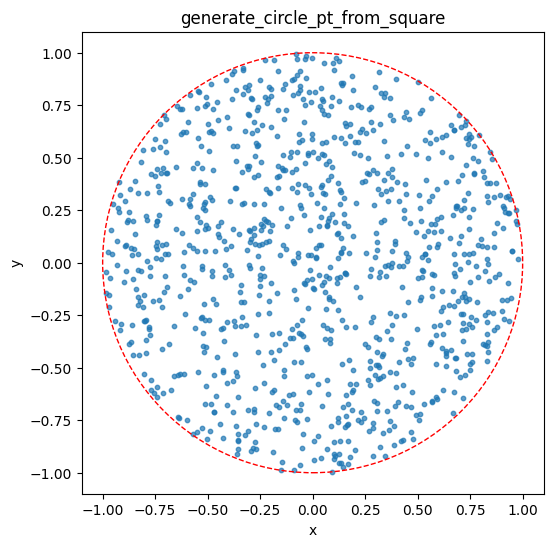

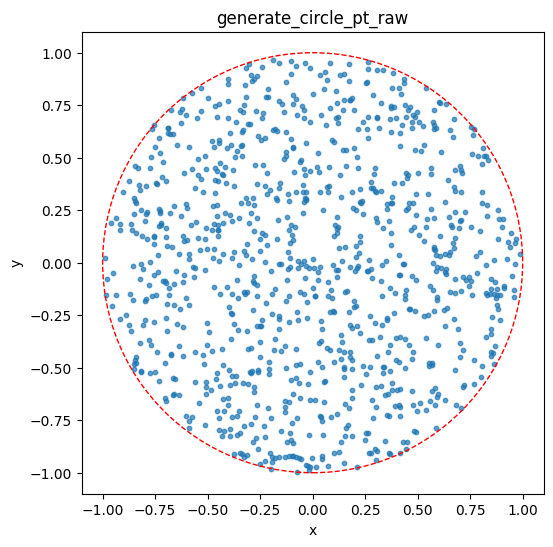

In [20]:
# As we can see, both of our solutions are completely uniform.
plot_generated_points(generate_circle_pt_from_square)
plot_generated_points(generate_circle_pt_raw)